# PyTorch로 이해하는 역전파 단계별 실습

이 노트북은 **역전파(Backpropagation)** 를 초보자가 이해할 수 있도록 다음 순서로 실습합니다.

1. Tensor와 자동 미분 이해
2. 단일 뉴런의 앞먹임 계산
3. 손실 함수 계산
4. `loss.backward()`로 기울기 계산
5. `optimizer.step()`으로 가중치 업데이트
6. 은닉층이 있는 다층 퍼셉트론에서 역전파 확인
7. XOR 예제로 반복 학습 과정 확인

In [1]:
# ============================================================
# 1. 기본 라이브러리 불러오기
# ============================================================

# torch는 PyTorch의 핵심 라이브러리입니다.
# Tensor 생성, 자동 미분, 신경망 학습에 사용합니다.
import torch

# torch.nn은 신경망 계층, 손실 함수 등을 제공하는 모듈입니다.
import torch.nn as nn

# torch.optim은 SGD, Adam 같은 최적화 알고리즘을 제공하는 모듈입니다.
import torch.optim as optim

# matplotlib은 학습 과정의 손실값 그래프를 그릴 때 사용합니다.
import matplotlib.pyplot as plt

# 실행할 때마다 같은 결과가 나오도록 난수 시드를 고정합니다.
torch.manual_seed(42)

# 현재 사용 중인 PyTorch 버전을 확인합니다.
print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


## 1단계. Tensor와 자동 미분 이해

PyTorch의 역전파는 `requires_grad=True`가 설정된 Tensor를 대상으로 자동으로 미분값을 계산합니다.

In [2]:
# ============================================================
# 2. Tensor와 자동 미분 기본 예제
# ============================================================

# x는 학습 대상처럼 미분값을 계산해야 하는 Tensor입니다.
# requires_grad=True는 x에 대한 기울기, 즉 미분값을 저장하겠다는 의미입니다.
x = torch.tensor(2.0, requires_grad=True)

# y = x^2 라는 간단한 함수를 정의합니다.
# x가 2이면 y는 4입니다.
y = x ** 2

# backward()는 y를 x에 대해 미분합니다.
# 수학적으로 y = x^2 이므로 dy/dx = 2x 입니다.
y.backward()

# x.grad에는 dy/dx 값이 저장됩니다.
# x=2이므로 dy/dx = 4입니다.
print("x 값:", x.item())
print("y = x^2 값:", y.item())
print("dy/dx 미분값:", x.grad.item())

x 값: 2.0
y = x^2 값: 4.0
dy/dx 미분값: 4.0


## 2단계. 단일 뉴런의 앞먹임 계산

신경망의 한 뉴런은 보통 다음 순서로 계산됩니다.

```text
입력값 x → 가중치 w와 곱함 → 편향 b를 더함 → 활성함수 적용 → 예측값 y_pred 생성
```

In [3]:
# ============================================================
# 3. 단일 뉴런의 앞먹임 계산
# ============================================================

# 입력값 x를 만듭니다.
# 여기서는 하나의 학습 데이터가 2개의 특성을 가진다고 가정합니다.
x = torch.tensor([[1.0, 2.0]])

# 정답값 y_true를 만듭니다.
# 이 예제에서는 정답이 1이라고 가정합니다.
y_true = torch.tensor([[1.0]])

# 가중치 w를 직접 생성합니다.
# requires_grad=True이므로 역전파 때 w의 기울기가 계산됩니다.
w = torch.tensor([[0.3], [0.7]], requires_grad=True)

# 편향 b를 직접 생성합니다.
# 편향도 학습되는 파라미터이므로 requires_grad=True로 설정합니다.
b = torch.tensor([[0.1]], requires_grad=True)

# 선형 계산을 수행합니다.
# z = x1*w1 + x2*w2 + b 입니다.
z = x @ w + b

# 시그모이드 활성함수를 적용합니다.
# sigmoid는 값을 0과 1 사이로 바꾸므로 이진 분류에서 자주 사용합니다.
y_pred = torch.sigmoid(z)

print("입력값 x:", x)
print("가중치 w:", w)
print("편향 b:", b)
print("선형 계산 z:", z.item())
print("시그모이드 예측값 y_pred:", y_pred.item())

입력값 x: tensor([[1., 2.]])
가중치 w: tensor([[0.3000],
        [0.7000]], requires_grad=True)
편향 b: tensor([[0.1000]], requires_grad=True)
선형 계산 z: 1.8000000715255737
시그모이드 예측값 y_pred: 0.8581488728523254


## 3단계. 손실 함수 계산

손실 함수는 모델의 예측값이 정답과 얼마나 다른지 계산합니다. 여기서는 이진 분류에 자주 사용하는 `BCELoss`를 사용합니다.

In [4]:
# ============================================================
# 4. 손실 함수 계산
# ============================================================

# BCELoss는 Binary Cross Entropy Loss입니다.
# 예측값이 0~1 사이의 확률일 때 사용하는 이진 분류 손실 함수입니다.
criterion = nn.BCELoss()

# 예측값 y_pred와 정답 y_true를 비교하여 손실값을 계산합니다.
loss = criterion(y_pred, y_true)

# 손실값이 작을수록 예측이 정답에 가깝다는 의미입니다.
print("손실값 loss:", loss.item())

손실값 loss: 0.15297769010066986


## 4단계. `backward()`로 역전파 수행

`loss.backward()`를 실행하면 PyTorch가 체인룰을 이용하여 각 가중치가 손실에 미치는 영향을 자동으로 계산합니다.

In [5]:
# ============================================================
# 5. 역전파 수행: loss.backward()
# ============================================================

# backward()는 손실값을 기준으로 w와 b의 기울기를 계산합니다.
# 이 기울기는 "손실을 줄이려면 가중치를 어느 방향으로 수정해야 하는가"를 알려줍니다.
loss.backward()

# w.grad는 손실값을 w로 미분한 값입니다.
# 각 가중치가 손실에 얼마나 영향을 주는지 나타냅니다.
print("w의 기울기 w.grad:")
print(w.grad)

# b.grad는 손실값을 b로 미분한 값입니다.
print("b의 기울기 b.grad:")
print(b.grad)

w의 기울기 w.grad:
tensor([[-0.1419],
        [-0.2837]])
b의 기울기 b.grad:
tensor([[-0.1419]])


## 5단계. 가중치 수동 업데이트

경사 하강법의 기본식은 다음과 같습니다.

```text
새 가중치 = 현재 가중치 - 학습률 × 기울기
```

In [6]:
# ============================================================
# 6. 가중치 수동 업데이트
# ============================================================

# 학습률을 설정합니다.
# 학습률은 한 번에 가중치를 얼마나 수정할지 결정합니다.
learning_rate = 0.1

# torch.no_grad()는 이 블록 안의 계산을 자동 미분 기록에서 제외합니다.
# 가중치를 직접 수정할 때는 기울기 계산 그래프를 만들 필요가 없습니다.
with torch.no_grad():
    # w에서 학습률 * 기울기를 빼서 손실이 줄어드는 방향으로 수정합니다.
    w -= learning_rate * w.grad

    # b도 같은 방식으로 수정합니다.
    b -= learning_rate * b.grad

# 수정된 가중치와 편향을 확인합니다.
print("업데이트 후 w:")
print(w)
print("업데이트 후 b:")
print(b)

# 주의: PyTorch는 grad 값을 자동으로 0으로 초기화하지 않습니다.
# 다음 학습 전에 반드시 grad를 0으로 초기화해야 합니다.
w.grad.zero_()
b.grad.zero_()

print("초기화 후 w.grad:")
print(w.grad)
print("초기화 후 b.grad:")
print(b.grad)

업데이트 후 w:
tensor([[0.3142],
        [0.7284]], requires_grad=True)
업데이트 후 b:
tensor([[0.1142]], requires_grad=True)
초기화 후 w.grad:
tensor([[0.],
        [0.]])
초기화 후 b.grad:
tensor([[0.]])


## 6단계. PyTorch Optimizer로 자동 업데이트

실제 학습에서는 가중치를 직접 수정하기보다 `optimizer.step()`을 사용합니다.

In [7]:
# ============================================================
# 7. nn.Linear와 optimizer를 사용한 단일 뉴런 학습
# ============================================================

# nn.Linear(2, 1)은 입력 특성 2개를 받아 출력 1개를 만드는 선형 계층입니다.
# 내부적으로 weight와 bias를 자동으로 생성합니다.
model = nn.Linear(2, 1)

# BCELoss는 이진 분류 손실 함수입니다.
criterion = nn.BCELoss()

# SGD는 가장 기본적인 경사 하강법 최적화 알고리즘입니다.
# model.parameters()는 모델 안의 모든 학습 가능한 파라미터를 의미합니다.
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 입력값과 정답값을 다시 준비합니다.
x = torch.tensor([[1.0, 2.0]])
y_true = torch.tensor([[1.0]])

# 1번 학습 과정을 직접 단계별로 확인합니다.
optimizer.zero_grad()              # 이전 기울기를 초기화합니다.
z = model(x)                       # 앞먹임: 선형 계산을 수행합니다.
y_pred = torch.sigmoid(z)          # 앞먹임: 시그모이드 활성함수를 적용합니다.
loss = criterion(y_pred, y_true)   # 손실값을 계산합니다.
loss.backward()                    # 역전파: 각 파라미터의 기울기를 계산합니다.

# optimizer.step() 전에 기울기를 확인합니다.
print("업데이트 전 손실값:", loss.item())
for name, param in model.named_parameters():
    print(name, "값:", param.data)
    print(name, "기울기:", param.grad)

optimizer.step()                   # 계산된 기울기를 이용하여 파라미터를 수정합니다.

# optimizer.step() 후 파라미터가 바뀌었는지 확인합니다.
print("업데이트 후 파라미터")
for name, param in model.named_parameters():
    print(name, "값:", param.data)

업데이트 전 손실값: 0.1926930993795395
weight 값: tensor([[0.5406, 0.5869]])
weight 기울기: tensor([[-0.1753, -0.3505]])
bias 값: tensor([-0.1657])
bias 기울기: tensor([-0.1753])
업데이트 후 파라미터
weight 값: tensor([[0.5581, 0.6220]])
bias 값: tensor([-0.1481])


## 7단계. 은닉층이 있는 다층 퍼셉트론에서 역전파 확인

다층 퍼셉트론에서는 출력층의 오차가 은닉층으로 거꾸로 전달됩니다. PyTorch는 이 과정을 `loss.backward()`로 자동 처리합니다.

In [8]:
# ============================================================
# 8. 은닉층이 있는 다층 퍼셉트론 모델 정의
# ============================================================

# nn.Module은 PyTorch에서 신경망 모델을 만들 때 상속하는 기본 클래스입니다.
class SimpleMLP(nn.Module):
    # __init__은 모델에 필요한 계층을 정의하는 부분입니다.
    def __init__(self):
        # 부모 클래스 nn.Module의 초기화 기능을 실행합니다.
        super().__init__()

        # 입력층에서 은닉층으로 가는 선형 계층입니다.
        # 입력 특성 2개를 받아 은닉 뉴런 3개로 변환합니다.
        self.hidden = nn.Linear(2, 3)

        # 은닉층에서 출력층으로 가는 선형 계층입니다.
        # 은닉 뉴런 3개를 받아 출력 1개를 만듭니다.
        self.output = nn.Linear(3, 1)

        # 시그모이드 활성함수입니다.
        # 값을 0과 1 사이로 변환합니다.
        self.sigmoid = nn.Sigmoid()

    # forward는 입력 데이터가 모델 안에서 계산되는 순서를 정의합니다.
    def forward(self, x):
        # 입력값을 은닉층 선형 계층에 통과시킵니다.
        hidden_linear = self.hidden(x)

        # 은닉층 결과에 시그모이드 활성함수를 적용합니다.
        hidden_output = self.sigmoid(hidden_linear)

        # 은닉층 출력을 출력층 선형 계층에 통과시킵니다.
        output_linear = self.output(hidden_output)

        # 최종 출력에 시그모이드 활성함수를 적용합니다.
        y_pred = self.sigmoid(output_linear)

        # 최종 예측값을 반환합니다.
        return y_pred

# 모델 객체를 생성합니다.
model = SimpleMLP()

# 모델 구조를 출력합니다.
print(model)

SimpleMLP(
  (hidden): Linear(in_features=2, out_features=3, bias=True)
  (output): Linear(in_features=3, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [10]:
# ============================================================
# 9. 다층 퍼셉트론에서 기울기 확인
# ============================================================

# 입력값 1개와 정답값 1개를 준비합니다.
x = torch.tensor([[1.0, 0.0]])
y_true = torch.tensor([[1.0]])

# 손실 함수와 최적화 알고리즘을 준비합니다.
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 이전 기울기를 초기화합니다.
optimizer.zero_grad()

# 앞먹임 단계: 예측값을 계산합니다.
y_pred = model(x)

# 손실값을 계산합니다.
loss = criterion(y_pred, y_true)

# 역전파 전에는 grad가 None입니다.
print("역전파 전")
for name, param in model.named_parameters():
    print(name, "grad:", param.grad)

# 역전파를 수행합니다.
loss.backward()

# 역전파 후에는 각 파라미터에 기울기가 계산됩니다.
print("역전파 후")
for name, param in model.named_parameters():
    print(name, "grad:")
    print(param.grad)

# 계산된 기울기를 이용하여 가중치를 업데이트합니다.
optimizer.step()

print("현재 손실값:", loss.item())
print("현재 예측값:", y_pred.item())

역전파 전
hidden.weight grad: None
hidden.bias grad: None
output.weight grad: None
output.bias grad: None
역전파 후
hidden.weight grad:
tensor([[-0.0432, -0.0000],
        [-0.0069, -0.0000],
        [-0.0263, -0.0000]])
hidden.bias grad:
tensor([-0.0432, -0.0069, -0.0263])
output.weight grad:
tensor([[-0.2169, -0.2772, -0.2580]])
output.bias grad:
tensor([-0.4073])
현재 손실값: 0.5230005383491516
현재 예측값: 0.5927393436431885


## 8단계. XOR 데이터로 반복 학습하기

XOR은 단순 선형 모델로는 해결하기 어렵지만, 은닉층이 있는 다층 퍼셉트론은 학습할 수 있습니다.

In [11]:
# ============================================================
# 10. XOR 데이터 준비
# ============================================================

# XOR 입력 데이터입니다.
# 두 입력값이 서로 다르면 1, 같으면 0입니다.
X = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

# XOR 정답 데이터입니다.
y = torch.tensor([
    [0.0],
    [1.0],
    [1.0],
    [0.0]
])

print("입력 데이터 X:")
print(X)
print("정답 데이터 y:")
print(y)

입력 데이터 X:
tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
정답 데이터 y:
tensor([[0.],
        [1.],
        [1.],
        [0.]])


In [12]:
# ============================================================
# 11. XOR 학습용 다층 퍼셉트론 정의
# ============================================================

class XORNet(nn.Module):
    def __init__(self):
        super().__init__()

        # 입력 2개를 은닉 뉴런 4개로 변환합니다.
        # XOR 문제는 비선형 문제이므로 은닉층이 필요합니다.
        self.hidden = nn.Linear(2, 4)

        # 은닉 뉴런 4개를 출력 1개로 변환합니다.
        self.output = nn.Linear(4, 1)

        # 시그모이드 활성함수를 사용합니다.
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # 입력층 → 은닉층 선형 계산
        x = self.hidden(x)

        # 은닉층 활성함수 적용
        x = self.sigmoid(x)

        # 은닉층 → 출력층 선형 계산
        x = self.output(x)

        # 출력층 활성함수 적용
        x = self.sigmoid(x)

        return x

# XOR 학습용 모델을 생성합니다.
model = XORNet()

# 이진 분류 손실 함수입니다.
criterion = nn.BCELoss()

# Adam은 SGD보다 안정적으로 학습되는 경우가 많은 최적화 알고리즘입니다.
optimizer = optim.Adam(model.parameters(), lr=0.1)

print(model)

XORNet(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [13]:
# ============================================================
# 12. XOR 모델 학습
# ============================================================

# 손실값 변화를 저장할 리스트입니다.
loss_history = []

# 전체 데이터를 5000번 반복 학습합니다.
# epoch는 전체 학습 데이터를 한 번 학습하는 단위입니다.
for epoch in range(5000):
    # 1. 이전 epoch에서 계산된 기울기를 초기화합니다.
    optimizer.zero_grad()

    # 2. 앞먹임 단계: 모델에 입력 데이터를 넣어 예측값을 계산합니다.
    y_pred = model(X)

    # 3. 손실 함수 계산: 예측값과 정답의 차이를 계산합니다.
    loss = criterion(y_pred, y)

    # 4. 역전파 단계: 손실값을 기준으로 모든 가중치의 기울기를 계산합니다.
    loss.backward()

    # 5. 가중치 업데이트: 계산된 기울기를 이용해 가중치를 수정합니다.
    optimizer.step()

    # 6. 그래프를 그리기 위해 손실값을 리스트에 저장합니다.
    loss_history.append(loss.item())

    # 500번마다 학습 상태를 출력합니다.
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:4d} | Loss: {loss.item():.6f}")

Epoch  500 | Loss: 0.001392
Epoch 1000 | Loss: 0.000456
Epoch 1500 | Loss: 0.000228
Epoch 2000 | Loss: 0.000135
Epoch 2500 | Loss: 0.000087
Epoch 3000 | Loss: 0.000060
Epoch 3500 | Loss: 0.000042
Epoch 4000 | Loss: 0.000031
Epoch 4500 | Loss: 0.000023
Epoch 5000 | Loss: 0.000017


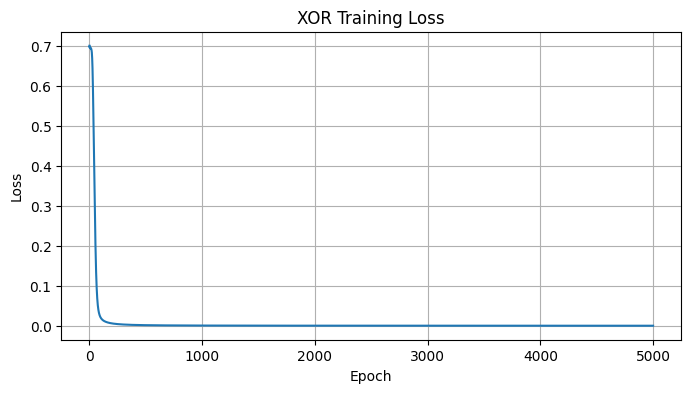

In [14]:
# ============================================================
# 13. 손실값 감소 그래프 확인
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 4))

# epoch별 손실값을 선 그래프로 그립니다.
plt.plot(loss_history)

# 그래프 제목을 설정합니다.
plt.title("XOR Training Loss")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("Loss")

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

In [15]:
# ============================================================
# 14. 학습된 XOR 모델 평가
# ============================================================

# 평가할 때는 기울기를 계산할 필요가 없으므로 no_grad()를 사용합니다.
with torch.no_grad():
    # 학습된 모델로 예측 확률을 계산합니다.
    pred_prob = model(X)

    # 예측 확률이 0.5 이상이면 1, 아니면 0으로 분류합니다.
    pred_class = (pred_prob >= 0.5).float()

print("예측 확률:")
print(pred_prob)

print("예측 클래스:")
print(pred_class)

print("실제 정답:")
print(y)

# 정확도를 계산합니다.
# pred_class와 y가 같은 위치의 개수를 평균으로 계산합니다.
accuracy = (pred_class == y).float().mean()
print("정확도:", accuracy.item())

예측 확률:
tensor([[4.9928e-06],
        [1.0000e+00],
        [9.9996e-01],
        [2.5094e-05]])
예측 클래스:
tensor([[0.],
        [1.],
        [1.],
        [0.]])
실제 정답:
tensor([[0.],
        [1.],
        [1.],
        [0.]])
정확도: 1.0


## 9단계. PyTorch 학습 코드와 역전파 개념 연결

아래 5줄은 대부분의 PyTorch 학습 코드에서 반복되는 핵심 구조입니다.

```python
optimizer.zero_grad()
y_pred = model(X)
loss = criterion(y_pred, y)
loss.backward()
optimizer.step()
```

각 줄의 의미는 다음과 같습니다.

| 코드 | 의미 |
|---|---|
| `optimizer.zero_grad()` | 이전 기울기 초기화 |
| `y_pred = model(X)` | 앞먹임 단계 |
| `loss = criterion(y_pred, y)` | 손실값 계산 |
| `loss.backward()` | 오류 후방 전파, 기울기 계산 |
| `optimizer.step()` | 가중치 업데이트 |

In [16]:
# ============================================================
# 15. 핵심 학습 코드 한 번 더 정리
# ============================================================

# 새로운 모델을 하나 만듭니다.
model = XORNet()

# 손실 함수와 최적화 알고리즘을 설정합니다.
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

# 1번의 학습 단계를 초보자용 설명과 함께 실행합니다.
optimizer.zero_grad()          # 1. 이전 기울기를 0으로 초기화합니다.
y_pred = model(X)              # 2. 앞먹임으로 예측값을 계산합니다.
loss = criterion(y_pred, y)    # 3. 예측값과 정답을 비교하여 손실값을 계산합니다.
loss.backward()                # 4. 역전파로 각 가중치의 기울기를 계산합니다.
optimizer.step()               # 5. 기울기를 이용해 가중치를 업데이트합니다.

print("1회 학습 후 손실값:", loss.item())

1회 학습 후 손실값: 0.6931236386299133


# 최종 정리

역전파는 다음 흐름으로 이해하면 됩니다.

```text
입력 데이터
↓
앞먹임으로 예측값 계산
↓
정답과 비교하여 손실값 계산
↓
loss.backward()로 각 가중치의 책임 계산
↓
optimizer.step()으로 가중치 수정
↓
반복하면서 손실 감소
```

반드시 기억해야 할 핵심은 다음입니다.

1. `forward()`는 예측값을 계산하는 과정입니다.
2. `loss`는 예측값이 얼마나 틀렸는지 나타내는 값입니다.
3. `loss.backward()`가 역전파를 수행합니다.
4. `.grad`에는 각 가중치의 기울기가 저장됩니다.
5. `optimizer.step()`이 실제 가중치를 수정합니다.
6. `optimizer.zero_grad()`를 하지 않으면 기울기가 누적되어 잘못 학습될 수 있습니다.